# Stage 1 - Feature Engineering
This notebook performs the exact preliminary split and Stage 1 transformations defined in `pipeline.md`, with all fitting done only on training data.

In [2]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOT_DIR = BASE_DIR / 'outputs' / 'plots' / 'stage1'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def save_plot(name: str):
    path = PLOT_DIR / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')


## Preliminary Split
Load the raw dataset, separate target variables, and perform the stratified 80/20 split before any feature engineering.

In [3]:
raw_path = RAW_DIR / 'alternate_credit_raw.csv'
df = pd.read_csv(raw_path)
print('Raw shape:', df.shape)
print(df[['defaulted']].value_counts(normalize=True).rename('rate'))

y = df['defaulted'].copy()
default_probability = df['default_probability'].copy()
X = df.drop(columns=['defaulted', 'default_probability']).copy()

X_train, X_test, y_train, y_test, dp_train, dp_test = train_test_split(
    X, y, default_probability, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

borrower_type_train = X_train['borrower_type'].copy()
borrower_type_test = X_test['borrower_type'].copy()
print('X_train shape:', X_train.shape, '| X_test shape:', X_test.shape)
print('y_train default rate:', y_train.mean(), '| y_test default rate:', y_test.mean())


Raw shape: (10000, 41)
defaulted
0            0.8499
1            0.1501
Name: rate, dtype: float64
X_train shape: (8000, 39) | X_test shape: (2000, 39)
y_train default rate: 0.150125 | y_test default rate: 0.15


## Step 1 - Compute `digital_footprint_density` (Pre-Imputation)
This preserves true digital-data availability before missing values are filled.

In [4]:
digital_fields = [
    'upi_transactions_per_month', 'upi_avg_transaction_amount', 'upi_months_active',
    'mobile_wallet_used', 'ecomm_orders_per_month', 'prepaid_orders_ratio'
]
for split_df in [X_train, X_test]:
    split_df['digital_footprint_density'] = split_df[digital_fields].notna().sum(axis=1) / len(digital_fields)

print(X_train['digital_footprint_density'].describe())
print(X_test['digital_footprint_density'].describe())


count    8000.000000
mean        0.852146
std         0.276824
min         0.166667
25%         0.833333
50%         1.000000
75%         1.000000
max         1.000000
Name: digital_footprint_density, dtype: float64
count    2000.000000
mean        0.857917
std         0.268537
min         0.166667
25%         0.833333
50%         1.000000
75%         1.000000
max         1.000000
Name: digital_footprint_density, dtype: float64


## Step 2 - Missingness Indicator Flags (Pre-Imputation)
These binary indicators retain the missingness signal as permanent model features.

In [5]:
for split_df in [X_train, X_test]:
    split_df['upi_data_missing'] = split_df['upi_transactions_per_month'].isna().astype(int)
    split_df['rent_data_missing'] = split_df['total_rental_months'].isna().astype(int)
    split_df['ecomm_data_missing'] = (
        split_df['ecomm_orders_per_month'].isna() | (split_df['ecomm_orders_per_month'] == 0)
    ).astype(int)

print('Train missing flags counts:')
print(X_train[['upi_data_missing', 'rent_data_missing', 'ecomm_data_missing']].sum())


Train missing flags counts:
upi_data_missing      1382
rent_data_missing     1672
ecomm_data_missing    1677
dtype: int64


## Step 3 - Two-Tier Imputation
Apply median imputation for low-missingness fields and borrower-type groupwise median imputation for structured missingness.

In [6]:
simple_cols = ['same_number_since_year', 'survey_q4', 'survey_q6']
simple_imputer = SimpleImputer(strategy='median')
X_train[simple_cols] = simple_imputer.fit_transform(X_train[simple_cols])
X_test[simple_cols] = simple_imputer.transform(X_test[simple_cols])

group_cols = [
    'upi_transactions_per_month', 'upi_avg_transaction_amount', 'upi_months_active',
    'mobile_wallet_used', 'rent_paid_on_time_months', 'total_rental_months'
]
group_medians = X_train[group_cols].assign(borrower_type=borrower_type_train).groupby('borrower_type').median(numeric_only=True)
global_medians = X_train[group_cols].median(numeric_only=True)

def apply_group_imputation(df_in: pd.DataFrame, bt: pd.Series):
    out = df_in.copy()
    for col in group_cols:
        fill_vals = bt.map(group_medians[col]).fillna(global_medians[col])
        out[col] = out[col].fillna(fill_vals)
    out['ecomm_return_rate'] = out['ecomm_return_rate'].fillna(0.0)
    out['prepaid_orders_ratio'] = out['prepaid_orders_ratio'].fillna(0.0)
    return out

X_train = apply_group_imputation(X_train, borrower_type_train)
X_test = apply_group_imputation(X_test, borrower_type_test)

if X_train.isna().sum().sum() > 0 or X_test.isna().sum().sum() > 0:
    raise ValueError('NaNs remain after imputation. Investigate imputation logic.')

print('Remaining NaNs train:', int(X_train.isna().sum().sum()))
print('Remaining NaNs test:', int(X_test.isna().sum().sum()))


Remaining NaNs train: 0
Remaining NaNs test: 0


## Step 4 - Derived Features
Create domain-derived payment, income, telecom, loan and UPI features, then remove redundant raw components.

In [7]:
INCOME_START = 1
INCOME_END = 6
INCOME_COLS = [f'income_month_{i}' for i in range(INCOME_START, INCOME_END + 1)]
TELECOM_REFERENCE_YEAR = 2024
LOAN_STRESS_SENTINEL = 999

def add_derived_features(df_in: pd.DataFrame):
    out = df_in.copy()
    out['utility_payment_ratio'] = np.where(
        out['utility_bills_total'] == 0,
        0.5,
        out['utility_bills_paid'] / out['utility_bills_total']
    )
    out['rent_consistency_score'] = np.where(
        out['rent_data_missing'] == 1,
        0.5,
        np.where(out['total_rental_months'] == 0, 0.5, out['rent_paid_on_time_months'] / out['total_rental_months'])
    )
    out['income_mean'] = out[INCOME_COLS].mean(axis=1)
    out['income_std'] = out[INCOME_COLS].std(axis=1)
    out['income_regularity_index'] = np.where(
        out['income_mean'] == 0,
        0,
        1 - (out['income_std'] / out['income_mean'])
    )
    out['income_regularity_index'] = out['income_regularity_index'].clip(0, 1)
    out['income_trend'] = out['income_month_6'] - out['income_month_1']
    out['telecom_stability_years'] = TELECOM_REFERENCE_YEAR - out['same_number_since_year']
    denom = out['income_mean'] * out['loan_tenure_months']
    out['loan_to_income_ratio'] = np.where(denom == 0, LOAN_STRESS_SENTINEL, out['loan_amount_requested'] / denom)
    out['upi_consistency_score'] = (out['upi_transactions_per_month'] / 120.0) * (out['upi_months_active'] / 36.0)
    out = out.drop(columns=INCOME_COLS + ['same_number_since_year', 'upi_transactions_per_month', 'upi_months_active'])
    return out

X_train = add_derived_features(X_train)
X_test = add_derived_features(X_test)
print('Post-derived train shape:', X_train.shape)
print(X_train[['utility_payment_ratio', 'income_mean', 'upi_consistency_score']].head())


Post-derived train shape: (8000, 43)
      utility_payment_ratio   income_mean  upi_consistency_score
5065               0.714286  18723.726667               0.132639
8072               0.227273  10114.360000               0.150694
1132               0.411765  22155.265000               0.113542
3553               0.625000  42534.500000               0.425833
4229               0.772727  19224.360000               0.150694


## Step 5 - Psychometric Composite Scores
Build composite psychometric factors with reverse-scoring for Q3 and Q7, then remove the original survey questions.

In [8]:
survey_cols = [f'survey_q{i}' for i in range(1, 9)]

def add_psych_composites(df_in: pd.DataFrame):
    out = df_in.copy()
    q3_rev = 6 - out['survey_q3']
    q7_rev = 6 - out['survey_q7']
    out['financial_discipline_score'] = pd.concat([out['survey_q1'], out['survey_q2'], q3_rev, out['survey_q4'], out['survey_q8']], axis=1).mean(axis=1)
    out['future_planning_score'] = pd.concat([out['survey_q5'], out['survey_q6']], axis=1).mean(axis=1)
    out['risk_appetite_score'] = pd.concat([q3_rev, q7_rev], axis=1).mean(axis=1)
    out = out.drop(columns=survey_cols)
    return out

X_train = add_psych_composites(X_train)
X_test = add_psych_composites(X_test)
print(X_train[['financial_discipline_score', 'future_planning_score', 'risk_appetite_score']].describe())


       financial_discipline_score  future_planning_score  risk_appetite_score
count                 8000.000000            8000.000000          8000.000000
mean                     2.986225               2.984437             2.990500
std                      0.679686               0.767985             0.792339
min                      1.200000               1.000000             1.000000
25%                      2.600000               2.500000             2.500000
50%                      3.000000               3.000000             3.000000
75%                      3.400000               3.500000             3.500000
max                      5.000000               5.000000             5.000000


## Step 6 - State to Region Mapping and One-Hot Encoding
Map states to regions, then one-hot encode required categorical variables using train-fitted encoder.

In [9]:
state_to_region = {
    'Delhi': 'North', 'Uttar Pradesh': 'North', 'Rajasthan': 'North',
    'Karnataka': 'South', 'Tamil Nadu': 'South', 'Telangana': 'South',
    'Maharashtra': 'West', 'Gujarat': 'West',
    'Bihar': 'East', 'Odisha': 'East',
    'Madhya Pradesh': 'Central'
}
for split_df in [X_train, X_test]:
    split_df['region'] = split_df['state'].map(state_to_region).fillna('Other')

identifier_cols = [c for c in ['borrower_id'] if c in X_train.columns]
if identifier_cols:
    print('Dropping identifier columns from model features:', identifier_cols)

categorical_cols = ['region', 'borrower_type', 'employment_type', 'loan_purpose']
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
train_cat = ohe.fit_transform(X_train[categorical_cols])
test_cat = ohe.transform(X_test[categorical_cols])
encoded_cols = ohe.get_feature_names_out(categorical_cols)

X_train = pd.concat([
    X_train.drop(columns=categorical_cols + ['state'] + identifier_cols).reset_index(drop=True),
    pd.DataFrame(train_cat, columns=encoded_cols)
], axis=1)
X_test = pd.concat([
    X_test.drop(columns=categorical_cols + ['state'] + identifier_cols).reset_index(drop=True),
    pd.DataFrame(test_cat, columns=encoded_cols)
], axis=1)

X_train.index = y_train.index
X_test.index = y_test.index
print('Encoded columns count:', len(encoded_cols))
print('Train shape after encoding:', X_train.shape)


Dropping identifier columns from model features: ['borrower_id']
Encoded columns count: 13
Train shape after encoding: (8000, 46)


## Step 7 - Discretization
Create train-derived quantile bins for loan amount and income level, then ordinal-encode and keep both raw and binned features.

In [10]:
loan_labels = ['Small', 'Medium', 'Large', 'Very_Large']
income_labels = ['Low', 'Medium', 'High']
loan_codes = {label: idx for idx, label in enumerate(loan_labels)}
income_codes = {label: idx for idx, label in enumerate(income_labels)}

_, loan_bins = pd.qcut(X_train['loan_amount_requested'], q=4, labels=loan_labels, retbins=True, duplicates='drop')
_, income_bins = pd.qcut(X_train['income_mean'], q=3, labels=income_labels, retbins=True, duplicates='drop')
loan_bins[0] = -np.inf
loan_bins[-1] = np.inf
income_bins[0] = -np.inf
income_bins[-1] = np.inf

X_train['loan_amount_bin'] = pd.cut(X_train['loan_amount_requested'], bins=loan_bins, labels=loan_labels, include_lowest=True).map(loan_codes).astype(int)
X_test['loan_amount_bin'] = pd.cut(X_test['loan_amount_requested'], bins=loan_bins, labels=loan_labels, include_lowest=True).map(loan_codes).astype(int)
X_train['income_level_bin'] = pd.cut(X_train['income_mean'], bins=income_bins, labels=income_labels, include_lowest=True).map(income_codes).astype(int)
X_test['income_level_bin'] = pd.cut(X_test['income_mean'], bins=income_bins, labels=income_labels, include_lowest=True).map(income_codes).astype(int)

print(X_train[['loan_amount_bin', 'income_level_bin']].describe())


       loan_amount_bin  income_level_bin
count      8000.000000       8000.000000
mean          1.499500          1.000000
std           1.118104          0.816599
min           0.000000          0.000000
25%           0.750000          0.000000
50%           1.000000          1.000000
75%           2.250000          2.000000
max           3.000000          2.000000


## Step 8 - Normalization
Scale only continuous columns using train-fitted MinMaxScaler while leaving one-hot, ordinal bins, and missingness flags unchanged.

In [11]:
flag_cols = ['upi_data_missing', 'rent_data_missing', 'ecomm_data_missing']
ordinal_cols = ['loan_amount_bin', 'income_level_bin']
binary_ohe_cols = [c for c in X_train.columns if set(pd.Series(X_train[c]).dropna().unique()).issubset({0, 1}) and c not in ordinal_cols + flag_cols]
exclude_cols = set(flag_cols + ordinal_cols + binary_ohe_cols)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
continuous_cols = [c for c in numeric_cols if c not in exclude_cols]
non_numeric_cols = [c for c in X_train.columns if c not in numeric_cols]
print('Non-numeric columns excluded from scaling:', non_numeric_cols)

scaler = MinMaxScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

train_min, train_max = X_train[continuous_cols].min().min(), X_train[continuous_cols].max().max()
print('Scaled continuous min/max (train):', train_min, train_max)
if train_min < -1e-8 or train_max > 1 + 1e-8:
    raise ValueError('Scaling bounds violation detected.')


Non-numeric columns excluded from scaling: []
Scaled continuous min/max (train): 0.0 1.0


## Step 9 - Exploratory PCA
Fit PCA on engineered training features, produce scree plot, and report components needed to explain 85% variance.

Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage1\stage1_scree_plot.png


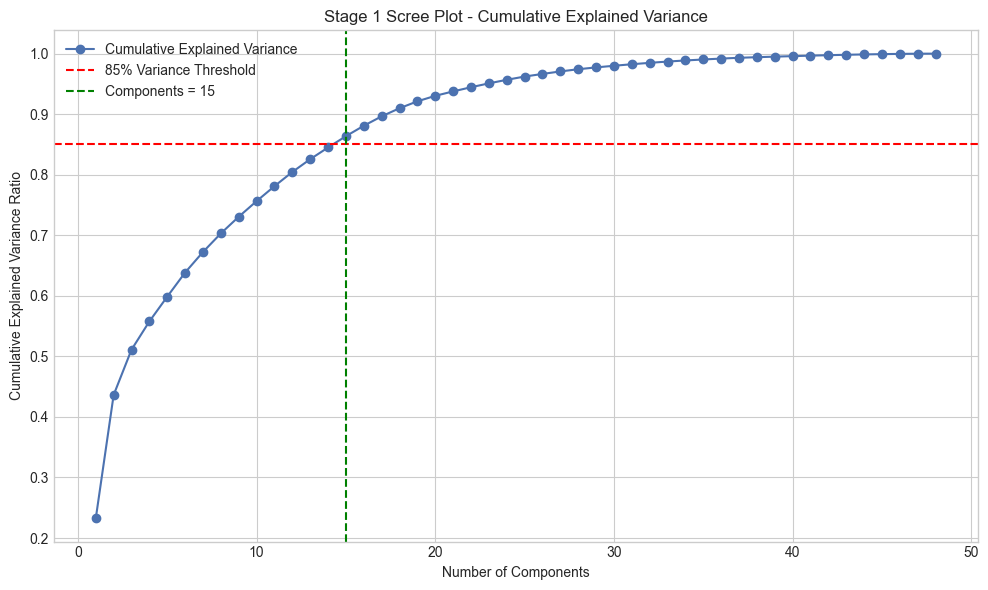

Components to explain 85% variance: 15


In [12]:
pca = PCA()
pca.fit(X_train)
cum_exp = np.cumsum(pca.explained_variance_ratio_)
target_var = 0.85
n_comp_85 = int(np.argmax(cum_exp >= target_var) + 1)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_exp) + 1), cum_exp, marker='o', label='Cumulative Explained Variance')
plt.axhline(target_var, color='red', linestyle='--', label='85% Variance Threshold')
plt.axvline(n_comp_85, color='green', linestyle='--', label=f'Components = {n_comp_85}')
plt.title('Stage 1 Scree Plot - Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.legend()
save_plot('stage1_scree_plot')
plt.show()
print('Components to explain 85% variance:', n_comp_85)


## Save Stage 1 Outputs
Persist engineered matrices, targets, and retained side variables for downstream stages.

In [13]:
stage1_output = {
    'X_train_eng': X_train,
    'X_test_eng': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'borrower_type_train': borrower_type_train,
    'borrower_type_test': borrower_type_test,
    'default_probability_test': dp_test,
    'n_comp_85': n_comp_85,
}
out_path = PROCESSED_DIR / 'stage1_outputs.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(stage1_output, f)
print('Saved:', out_path)
print('Output shapes:', X_train.shape, X_test.shape)


Saved: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage1_outputs.pkl
Output shapes: (8000, 48) (2000, 48)


## Stage 1 Summary

In [14]:
print('=' * 70)
print('STAGE 1 SUMMARY')
print('- Completed preliminary split and full feature engineering pipeline.')
print(f"- Saved engineered train/test matrices to: {out_path}")
print(f"- X_train_eng shape: {X_train.shape}")
print(f"- X_test_eng shape: {X_test.shape}")
print(f"- Train default rate: {y_train.mean():.4f}")
print(f"- Test default rate: {y_test.mean():.4f}")
print(f"- PCA components for 85% variance: {n_comp_85}")
print('=' * 70)


STAGE 1 SUMMARY
- Completed preliminary split and full feature engineering pipeline.
- Saved engineered train/test matrices to: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage1_outputs.pkl
- X_train_eng shape: (8000, 48)
- X_test_eng shape: (2000, 48)
- Train default rate: 0.1501
- Test default rate: 0.1500
- PCA components for 85% variance: 15


In [15]:
inference_s1 = {
    'simple_imputer': simple_imputer,
    'group_medians': group_medians,
    'global_medians': global_medians,
    'ohe': ohe,
    'scaler': scaler,
    'loan_bins': loan_bins,
    'income_bins': income_bins,
    'continuous_cols': continuous_cols,
    'feature_columns': list(X_train.columns),  # AFTER scaling, BEFORE cluster_id
}
with open(PROCESSED_DIR / 'inference_artifacts_stage1.pkl', 'wb') as f:
    pickle.dump(inference_s1, f)
